Question 10

In [1]:
import numpy as np

# ── Data ────────────────────────────────────────────────────────────────────
prices = np.array([
    [100, 108, 103, 115, 110, 119, 125, 121, 130, 127, 135, 140],  # Stock A
    [200, 195, 210, 205, 220, 215, 225, 230, 222, 235, 240, 238],  # Stock B
])

# ── (a) Monthly simple returns  Rt = (Pt - Pt-1) / Pt-1  ─────────────────
# Numerator  : prices[:, 1:]  - prices[:, :-1]   → shape (2, 11)
# Denominator: prices[:, :-1]                    → shape (2, 11)
simple_returns = (prices[:, 1:] - prices[:, :-1]) / prices[:, :-1]

print("=" * 60)
print("(a) Monthly Simple Returns  [shape: {}]".format(simple_returns.shape))
print("-" * 60)
labels = ["Stock A", "Stock B"]
for i, lbl in enumerate(labels):
    formatted = [f"{r:+.4f}" for r in simple_returns[i]]
    print(f"{lbl}: {formatted}")

# ── (b) Annualised mean return and annualised standard deviation ──────────
monthly_mean = simple_returns.mean(axis=1)          # shape (2,)
monthly_std  = simple_returns.std(axis=1, ddof=1)   # sample std, shape (2,)

annual_mean  = monthly_mean * 12
annual_std   = monthly_std  * np.sqrt(12)

print("\n" + "=" * 60)
print("(b) Annualised Statistics")
print("-" * 60)
for i, lbl in enumerate(labels):
    print(f"{lbl}:")
    print(f"  Monthly  mean = {monthly_mean[i]:.6f}  |  std = {monthly_std[i]:.6f}")
    print(f"  Annual   mean = {annual_mean[i]:.4%}  |  std = {annual_std[i]:.4%}")

# ── (c) Sample covariance matrix and verification ─────────────────────────
# np.cov expects each ROW to be a variable → shape already (2, 11) ✓
cov_matrix = np.cov(simple_returns)   # shape (2, 2)

sigma_A = monthly_std[0]
sigma_B = monthly_std[1]
rho_AB  = np.corrcoef(simple_returns)[0, 1]

cov_AB_formula = rho_AB * sigma_A * sigma_B   # = ρ·σA·σB
cov_AB_matrix  = cov_matrix[0, 1]             # off-diagonal entry

print("\n" + "=" * 60)
print("(c) 2×2 Sample Covariance Matrix")
print("-" * 60)
print(np.array2string(cov_matrix, precision=8, suppress_small=True))
print(f"\nOff-diagonal (from matrix)  : {cov_AB_matrix:.8f}")
print(f"ρ · σA · σB  (formula check): {cov_AB_formula:.8f}")
print(f"Correlation ρ_AB            : {rho_AB:.6f}")
match = np.isclose(cov_AB_matrix, cov_AB_formula)
print(f"Values match (np.isclose)   : {match}")


(a) Monthly Simple Returns  [shape: (2, 11)]
------------------------------------------------------------
Stock A: ['+0.0800', '-0.0463', '+0.1165', '-0.0435', '+0.0818', '+0.0504', '-0.0320', '+0.0744', '-0.0231', '+0.0630', '+0.0370']
Stock B: ['-0.0250', '+0.0769', '-0.0238', '+0.0732', '-0.0227', '+0.0465', '+0.0222', '-0.0348', '+0.0586', '+0.0213', '-0.0083']

(b) Annualised Statistics
------------------------------------------------------------
Stock A:
  Monthly  mean = 0.032573  |  std = 0.058311
  Annual   mean = 39.0874%  |  std = 20.1994%
Stock B:
  Monthly  mean = 0.016728  |  std = 0.042095
  Annual   mean = 20.0738%  |  std = 14.5820%

(c) 2×2 Sample Covariance Matrix
------------------------------------------------------------
[[ 0.00340013 -0.00206426]
 [-0.00206426  0.00177196]]

Off-diagonal (from matrix)  : -0.00206426
ρ · σA · σB  (formula check): -0.00206426
Correlation ρ_AB            : -0.840987
Values match (np.isclose)   : True


Question 11

In [2]:
import numpy as np

np.random.seed(42)   # reproducibility

# ── Parameters from Q6 ───────────────────────────────────────────────────
mu = np.array([0.15, 0.08, 0.05])   # expected annual returns

# Volatilities
sigma = np.array([0.25, 0.12, 0.04])

# Correlation matrix
rho = np.array([
    [1.0, 0.4, 0.1],
    [0.4, 1.0, 0.2],
    [0.1, 0.2, 1.0],
])

# Covariance matrix Σ_ij = ρ_ij · σ_i · σ_j
# Outer product of sigma gives the σ_i·σ_j matrix
Sigma = rho * np.outer(sigma, sigma)

print("=" * 60)
print("Covariance Matrix Σ")
print("-" * 60)
print(np.array2string(Sigma, precision=6, suppress_small=True))

# ── (a) Equal-weight portfolio ────────────────────────────────────────────
w_eq = np.array([1/3, 1/3, 1/3])

E_Rp_eq   = w_eq @ mu                    # w⊤ μ
var_p_eq  = w_eq @ Sigma @ w_eq          # w⊤ Σ w
sigma_p_eq = np.sqrt(var_p_eq)

print("\n" + "=" * 60)
print("(a) Equal-Weight Portfolio  w = [1/3, 1/3, 1/3]")
print("-" * 60)
print(f"  E[Rp]     = w⊤μ      = {E_Rp_eq:.6f}  ({E_Rp_eq:.4%})")
print(f"  Var(Rp)   = w⊤Σw     = {var_p_eq:.6f}")
print(f"  σp        = √Var(Rp)  = {sigma_p_eq:.6f}  ({sigma_p_eq:.4%})")

# ── (b) 10 000 random portfolios via Dirichlet ────────────────────────────
N_SIM = 10_000
# Dirichlet(1,1,1) samples uniformly from the simplex (weights sum to 1, all ≥ 0)
W = np.random.dirichlet(np.ones(3), size=N_SIM)   # shape (10000, 3)

# Vectorised E[Rp] for all portfolios at once
E_all   = W @ mu                                   # shape (10000,)

# Vectorised σp: σp_i² = w_i⊤ Σ w_i = diag(W Σ W⊤)
# Efficient: (W @ Sigma) element-wise * W → sum over assets
var_all   = np.sum((W @ Sigma) * W, axis=1)        # shape (10000,)
sigma_all = np.sqrt(var_all)                        # shape (10000,)

print("\n" + "=" * 60)
print(f"(b) 10 000 Random Portfolios  [E_all shape: {E_all.shape},"
      f"  sigma_all shape: {sigma_all.shape}]")
print("-" * 60)
print(f"  E[Rp]  range: [{E_all.min():.4%}, {E_all.max():.4%}]")
print(f"  σp     range: [{sigma_all.min():.4%}, {sigma_all.max():.4%}]")

# ── (c) Sharpe Ratios for all 10 000 portfolios ───────────────────────────
Rf = 0.04   # risk-free rate 4%

sharpe_all = (E_all - Rf) / sigma_all              # shape (10000,) — no loop

idx_max    = np.argmax(sharpe_all)
max_sharpe = sharpe_all[idx_max]
best_w     = W[idx_max]

print("\n" + "=" * 60)
print("(c) Sharpe Ratios  (Rf = 4%)")
print("-" * 60)
print(f"  Maximum Sharpe Ratio : {max_sharpe:.6f}")
print(f"  Corresponding weights: {np.round(best_w, 6)}")
print(f"    Asset 1 (μ=15%)    : {best_w[0]:.4%}")
print(f"    Asset 2 (μ= 8%)    : {best_w[1]:.4%}")
print(f"    Asset 3 (μ= 5%)    : {best_w[2]:.4%}")
print(f"  Portfolio E[Rp]      : {E_all[idx_max]:.4%}")
print(f"  Portfolio σp         : {sigma_all[idx_max]:.4%}")


Covariance Matrix Σ
------------------------------------------------------------
[[0.0625  0.012   0.001  ]
 [0.012   0.0144  0.00096]
 [0.001   0.00096 0.0016 ]]

(a) Equal-Weight Portfolio  w = [1/3, 1/3, 1/3]
------------------------------------------------------------
  E[Rp]     = w⊤μ      = 0.093333  (9.3333%)
  Var(Rp)   = w⊤Σw     = 0.011824
  σp        = √Var(Rp)  = 0.108740  (10.8740%)

(b) 10 000 Random Portfolios  [E_all shape: (10000,),  sigma_all shape: (10000,)]
------------------------------------------------------------
  E[Rp]  range: [5.0674%, 14.9855%]
  σp     range: [3.9635%, 24.9588%]

(c) Sharpe Ratios  (Rf = 4%)
------------------------------------------------------------
  Maximum Sharpe Ratio : 0.505292
  Corresponding weights: [0.203432 0.171487 0.625081]
    Asset 1 (μ=15%)    : 20.3432%
    Asset 2 (μ= 8%)    : 17.1487%
    Asset 3 (μ= 5%)    : 62.5081%
  Portfolio E[Rp]      : 7.5488%
  Portfolio σp         : 7.0232%


Question 12

In [3]:
import numpy as np

# ── Parameters ───────────────────────────────────────────────────────────
mu1,  mu2  = 0.12, 0.06
sig1, sig2 = 0.20, 0.10
w1,   w2   = 0.60, 0.40

# ── (a) σp for 200 correlation values in [−1, +1] — no Python loops ──────
rho_vals = np.linspace(-1, 1, 200)   # shape (200,)

# Portfolio variance formula (vectorised):
# σp² = w1²σ1² + w2²σ2² + 2·w1·w2·ρ·σ1·σ2
var_p = (w1**2 * sig1**2
         + w2**2 * sig2**2
         + 2 * w1 * w2 * rho_vals * sig1 * sig2)   # shape (200,)

sigma_p = np.sqrt(var_p)   # shape (200,)

print("=" * 60)
print("(a) σp for 200 ρ values  [shape: {}]".format(sigma_p.shape))
print("-" * 60)
print(f"  ρ = -1.0  →  σp = {sigma_p[0]:.6f}  ({sigma_p[0]:.4%})")
print(f"  ρ =  0.0  →  σp = {sigma_p[99]:.6f}  ({sigma_p[99]:.4%})")
print(f"  ρ = +1.0  →  σp = {sigma_p[-1]:.6f}  ({sigma_p[-1]:.4%})")

# ── (b) ρ at which σp is minimised ───────────────────────────────────────
idx_min    = np.argmin(sigma_p)
rho_min    = rho_vals[idx_min]
sigma_min  = sigma_p[idx_min]

print("\n" + "=" * 60)
print("(b) Minimum σp")
print("-" * 60)
print(f"  ρ at minimum σp : {rho_min:.6f}  (closest grid point to −1)")
print(f"  Minimum σp      : {sigma_min:.6f}  ({sigma_min:.4%})")
print(f"  (Grid step = {rho_vals[1]-rho_vals[0]:.6f}; true minimum is at ρ = −1 — see (c))")

# ── (c) Analytical verification that minimum is always at ρ = −1 ─────────
# σp² = w1²σ1² + w2²σ2² + 2·w1·w2·ρ·σ1·σ2
#
# d(σp²)/dρ = 2·w1·w2·σ1·σ2
#
# Since w1, w2 > 0 and σ1, σ2 > 0:
#   d(σp²)/dρ = 2·(0.6)(0.4)(0.20)(0.10) > 0   always
#
# σp² is strictly INCREASING in ρ ⟹ minimum at ρ = −1 (left boundary).

d_var_d_rho = 2 * w1 * w2 * sig1 * sig2   # constant; sign determines monotonicity

print("\n" + "=" * 60)
print("(c) Analytical Verification")
print("-" * 60)
print("  σp²(ρ) = w1²σ1² + w2²σ2² + 2·w1·w2·ρ·σ1·σ2")
print("  d(σp²)/dρ = 2·w1·w2·σ1·σ2  (independent of ρ)")
print(f"            = 2 × {w1} × {w2} × {sig1} × {sig2}")
print(f"            = {d_var_d_rho:.6f}  > 0")
print()
print("  Because d(σp²)/dρ > 0 for all ρ, σp² is strictly increasing in ρ.")
print("  The minimum is therefore always attained at ρ = −1 (boundary).")
print()

# Exact minimum at ρ = −1
var_at_minus1  = w1**2 * sig1**2 + w2**2 * sig2**2 + 2*w1*w2*(-1)*sig1*sig2
sigma_at_minus1 = np.sqrt(var_at_minus1)

# Perfect negative correlation: σp = |w1·σ1 - w2·σ2|
sigma_closed = abs(w1*sig1 - w2*sig2)

print(f"  Exact σp at ρ = −1 (NumPy formula): {sigma_at_minus1:.6f}  ({sigma_at_minus1:.4%})")
print(f"  Closed form |w1σ1 − w2σ2|         : {sigma_closed:.6f}  ({sigma_closed:.4%})")
print(f"  Values agree (np.isclose): {np.isclose(sigma_at_minus1, sigma_closed)}")


(a) σp for 200 ρ values  [shape: (200,)]
------------------------------------------------------------
  ρ = -1.0  →  σp = 0.080000  (8.0000%)
  ρ =  0.0  →  σp = 0.126300  (12.6300%)
  ρ = +1.0  →  σp = 0.160000  (16.0000%)

(b) Minimum σp
------------------------------------------------------------
  ρ at minimum σp : -1.000000  (closest grid point to −1)
  Minimum σp      : 0.080000  (8.0000%)
  (Grid step = 0.010050; true minimum is at ρ = −1 — see (c))

(c) Analytical Verification
------------------------------------------------------------
  σp²(ρ) = w1²σ1² + w2²σ2² + 2·w1·w2·ρ·σ1·σ2
  d(σp²)/dρ = 2·w1·w2·σ1·σ2  (independent of ρ)
            = 2 × 0.6 × 0.4 × 0.2 × 0.1
            = 0.009600  > 0

  Because d(σp²)/dρ > 0 for all ρ, σp² is strictly increasing in ρ.
  The minimum is therefore always attained at ρ = −1 (boundary).

  Exact σp at ρ = −1 (NumPy formula): 0.080000  (8.0000%)
  Closed form |w1σ1 − w2σ2|         : 0.080000  (8.0000%)
  Values agree (np.isclose): True


Question 13

In [4]:
import pandas as pd
import numpy as np

# ── Build the simulated price DataFrame (exact code from the question) ────
np.random.seed(0)
dates      = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly  = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly = np.array([0.04,  0.03,  0.02,  0.025])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim  = 100 * np.cumprod(1 + returns_sim, axis=0)

df = pd.DataFrame(prices_sim, index=dates,
                  columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])

print("=" * 60)
print("Simulated Closing Prices  (first 3 rows)")
print("-" * 60)
print(df.head(3).to_string())

# ── (a) Weekly simple returns ─────────────────────────────────────────────
df_returns = df.pct_change().dropna()

print("\n" + "=" * 60)
print(f"(a) Weekly Simple Returns  [shape: {df_returns.shape}]")
print("-" * 60)
print("First 3 rows:")
print(df_returns.head(3).to_string())

# ── (b) Descriptive statistics ────────────────────────────────────────────
desc = df_returns.describe()

print("\n" + "=" * 60)
print("(b) Descriptive Statistics")
print("-" * 60)
print(desc.to_string())

highest_mean_asset = desc.loc['mean'].idxmax()
highest_std_asset  = desc.loc['std'].idxmax()
print(f"\n  Asset with highest mean return : {highest_mean_asset}"
      f"  ({desc.loc['mean', highest_mean_asset]:.6f})")
print(f"  Asset with highest std dev     : {highest_std_asset}"
      f"  ({desc.loc['std',  highest_std_asset]:.6f})")

# ── (c) Annualised Sharpe Ratio (Rf = 2% annualised) — Pandas only ───────
# Weekly Rf = 2% / 52
Rf_annual  = 0.02
Rf_weekly  = Rf_annual / 52

# Annualised mean  = weekly mean × 52
# Annualised std   = weekly std  × √52
annual_mean = df_returns.mean() * 52
annual_std  = df_returns.std()  * np.sqrt(52)
sharpe      = (annual_mean - Rf_annual) / annual_std   # Pandas Series, no loop

print("\n" + "=" * 60)
print(f"(c) Annualised Sharpe Ratios  (Rf = {Rf_annual:.0%} p.a.)")
print("-" * 60)
summary = pd.DataFrame({
    'Ann. Mean Return': annual_mean.map('{:.4%}'.format),
    'Ann. Std Dev'    : annual_std.map('{:.4%}'.format),
    'Sharpe Ratio'    : sharpe.map('{:.4f}'.format),
})
print(summary.to_string())
print(f"\n  Best Sharpe: {sharpe.idxmax()}  ({sharpe.max():.4f})")


Simulated Closing Prices  (first 3 rows)
------------------------------------------------------------
                  AAPL        MSFT       GOOGL        AMZN
2023-01-02  107.356209  101.400472  102.057476  105.752233
2023-01-09  115.698036   98.630379  104.098806  105.510702
2023-01-16  115.567441  100.042565  104.502800  109.505004

(a) Weekly Simple Returns  [shape: (51, 4)]
------------------------------------------------------------
First 3 rows:
                AAPL      MSFT     GOOGL      AMZN
2023-01-09  0.077702 -0.027318  0.020002 -0.002284
2023-01-16 -0.001129  0.014318  0.003881  0.037857
2023-01-23  0.033442  0.005650  0.009877  0.009842

(b) Descriptive Statistics
------------------------------------------------------------
            AAPL       MSFT      GOOGL       AMZN
count  51.000000  51.000000  51.000000  51.000000
mean    0.005603   0.002192  -0.000887   0.006094
std     0.045641   0.032819   0.017055   0.022948
min    -0.099120  -0.057424  -0.033125  -0.054085

Question 14

In [5]:
import pandas as pd
import numpy as np

# ── Reproduce the same price and returns DataFrames from Q13 ─────────────
np.random.seed(0)
dates       = pd.date_range('2023-01-02', periods=52, freq='W-MON')
mu_weekly   = np.array([0.003, 0.002, 0.001, 0.0015])
sig_weekly  = np.array([0.04,  0.03,  0.02,  0.025])
returns_sim = np.random.normal(mu_weekly, sig_weekly, (52, 4))
prices_sim  = 100 * np.cumprod(1 + returns_sim, axis=0)

df          = pd.DataFrame(prices_sim, index=dates,
                            columns=['AAPL', 'MSFT', 'GOOGL', 'AMZN'])
df_returns  = df.pct_change().dropna()   # shape (51, 4)

# ── (a) 4×4 Correlation Matrix ────────────────────────────────────────────
corr_matrix = df_returns.corr()

print("=" * 60)
print("(a) Correlation Matrix")
print("-" * 60)
print(corr_matrix.to_string())

# Find the pair with the lowest off-diagonal correlation
# Mask the diagonal with NaN so we don't pick ρ=1 for same asset
arr = corr_matrix.values.copy()   # writeable copy of the underlying array
np.fill_diagonal(arr, np.nan)
corr_no_diag = pd.DataFrame(arr, index=corr_matrix.index, columns=corr_matrix.columns)

min_val   = corr_no_diag.min().min()
min_loc   = corr_no_diag.stack().idxmin()   # (asset_i, asset_j) tuple
print(f"\n  Lowest off-diagonal correlation : {min_val:.6f}"
      f"  ({min_loc[0]} vs {min_loc[1]})")

# ── (b) Equal-weight portfolio return series ──────────────────────────────
weights = pd.Series({'AAPL': 0.25, 'MSFT': 0.25, 'GOOGL': 0.25, 'AMZN': 0.25})

# dot product: each row of df_returns dotted with weights → scalar per date
port_returns = df_returns.dot(weights)   # Pandas Series, shape (51,)

print("\n" + "=" * 60)
print("(b) Equal-Weight Portfolio Return Series")
print("-" * 60)
print(f"  Shape       : {port_returns.shape}")
print(f"  Weekly mean : {port_returns.mean():.6f}  ({port_returns.mean():.4%})")
print(f"  Weekly std  : {port_returns.std():.6f}  ({port_returns.std():.4%})")
print("\n  First 5 weekly returns:")
print(port_returns.head().to_string())

# ── (c) Resample to monthly, then report mean and std ────────────────────
# Aggregate weekly → monthly using compound return:
#   R_month = ∏(1 + R_week) - 1
def compound(r):
    return (1 + r).prod() - 1

monthly_returns = port_returns.resample('ME').apply(compound)

print("\n" + "=" * 60)
print("(c) Monthly Portfolio Returns  (compounded from weekly)")
print("-" * 60)
print(monthly_returns.to_string())
print(f"\n  Number of months : {len(monthly_returns)}")
print(f"  Mean             : {monthly_returns.mean():.6f}  ({monthly_returns.mean():.4%})")
print(f"  Std Dev          : {monthly_returns.std():.6f}   ({monthly_returns.std():.4%})")


(a) Correlation Matrix
------------------------------------------------------------
           AAPL      MSFT     GOOGL      AMZN
AAPL   1.000000 -0.075324  0.190733  0.060147
MSFT  -0.075324  1.000000  0.287278  0.069544
GOOGL  0.190733  0.287278  1.000000 -0.001252
AMZN   0.060147  0.069544 -0.001252  1.000000

  Lowest off-diagonal correlation : -0.075324  (AAPL vs MSFT)

(b) Equal-Weight Portfolio Return Series
------------------------------------------------------------
  Shape       : (51,)
  Weekly mean : 0.003251  (0.3251%)
  Weekly std  : 0.016956  (1.6956%)

  First 5 weekly returns:
2023-01-09    0.017025
2023-01-16    0.013732
2023-01-23    0.014703
2023-01-30    0.011504
2023-02-06   -0.019069
Freq: W-MON

(c) Monthly Portfolio Returns  (compounded from weekly)
------------------------------------------------------------
2023-01-31    0.058185
2023-02-28    0.001390
2023-03-31   -0.022310
2023-04-30   -0.036822
2023-05-31    0.011764
2023-06-30    0.051925
2023-07-31    0.

Question 15

Saved → week1_plots.png


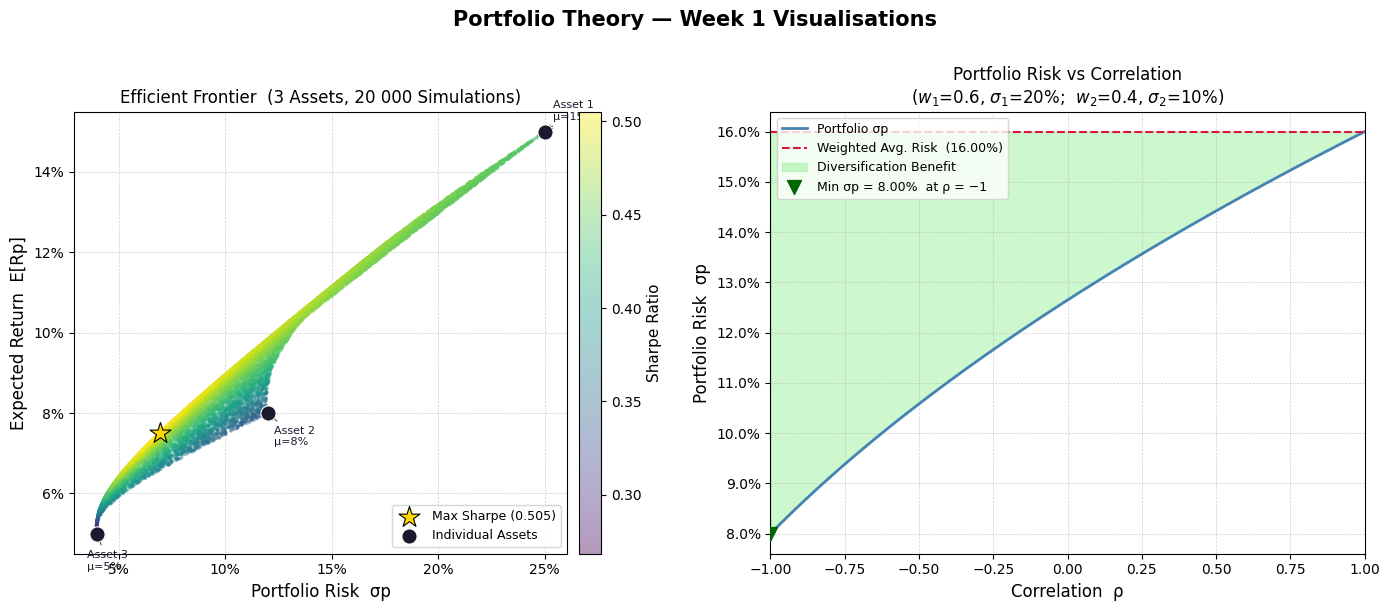

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

np.random.seed(42)

# ════════════════════════════════════════════════════════════════════════════
# Data Setup
# ════════════════════════════════════════════════════════════════════════════

# ── 3-Asset universe (from Q6 / Q11) ────────────────────────────────────
mu    = np.array([0.15, 0.08, 0.05])
sigma = np.array([0.25, 0.12, 0.04])
rho   = np.array([[1.0, 0.4, 0.1],
                   [0.4, 1.0, 0.2],
                   [0.1, 0.2, 1.0]])
Sigma = rho * np.outer(sigma, sigma)
Rf    = 0.04
tickers = ['Asset 1\nμ=15%', 'Asset 2\nμ=8%', 'Asset 3\nμ=5%']

# ── Simulate 20 000 random portfolios ───────────────────────────────────
N_SIM = 20_000
W     = np.random.dirichlet(np.ones(3), size=N_SIM)          # (20000, 3)
E_all = W @ mu                                                 # (20000,)
var_all   = np.sum((W @ Sigma) * W, axis=1)                   # (20000,)
sig_all   = np.sqrt(var_all)                                   # (20000,)
sharpe_all = (E_all - Rf) / sig_all                            # (20000,)

# Max-Sharpe portfolio
idx_max = np.argmax(sharpe_all)

# Individual asset σp (weight=1 in that asset)
asset_sig = sigma
asset_ret = mu

# ── 2-Asset correlation sensitivity (from Q12) ──────────────────────────
mu1, mu2   = 0.12, 0.06
s1,  s2    = 0.20, 0.10
w1,  w2    = 0.60, 0.40
rho_grid   = np.linspace(-1, 1, 200)
var_2a     = w1**2*s1**2 + w2**2*s2**2 + 2*w1*w2*rho_grid*s1*s2
sig_2a     = np.sqrt(var_2a)
wa_risk    = w1*s1 + w2*s2   # weighted-average risk

# ════════════════════════════════════════════════════════════════════════════
# Figure
# ════════════════════════════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Portfolio Theory — Week 1 Visualisations',
             fontsize=15, fontweight='bold', y=1.01)

# ─── Subplot 1: Efficient Frontier Scatter ───────────────────────────────
sc = ax1.scatter(sig_all, E_all,
                 c=sharpe_all, cmap='viridis',
                 alpha=0.4, s=6, linewidths=0, zorder=2)

# Colorbar
cbar = fig.colorbar(sc, ax=ax1, pad=0.02)
cbar.set_label('Sharpe Ratio', fontsize=11)

# Max-Sharpe star
ax1.scatter(sig_all[idx_max], E_all[idx_max],
            marker='*', s=250, color='gold',
            edgecolors='k', linewidths=0.8,
            zorder=5, label=f'Max Sharpe ({sharpe_all[idx_max]:.3f})')

# Individual assets
ax1.scatter(asset_sig, asset_ret,
            marker='o', s=120, color='#1a1a2e',
            edgecolors='white', linewidths=0.8,
            zorder=6, label='Individual Assets')

# Annotations for individual assets
offsets = [(0.004, 0.003), (0.003, -0.008), (-0.005, -0.009)]
for i, (lbl, ox, oy) in enumerate(zip(tickers,
                                       [o[0] for o in offsets],
                                       [o[1] for o in offsets])):
    ax1.annotate(lbl,
                 xy=(asset_sig[i], asset_ret[i]),
                 xytext=(asset_sig[i]+ox, asset_ret[i]+oy),
                 fontsize=8, color='#1a1a2e',
                 arrowprops=dict(arrowstyle='->', color='#555', lw=0.8))

# Axis formatting
ax1.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))
ax1.set_xlabel('Portfolio Risk  σp', fontsize=12)
ax1.set_ylabel('Expected Return  E[Rp]', fontsize=12)
ax1.set_title('Efficient Frontier  (3 Assets, 20 000 Simulations)', fontsize=12)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# ─── Subplot 2: Correlation Sensitivity ─────────────────────────────────
ax2.plot(rho_grid, sig_2a, color='steelblue', linewidth=2.0,
         label='Portfolio σp')

# Horizontal dashed line at weighted-average risk
ax2.axhline(wa_risk, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Weighted Avg. Risk  ({wa_risk:.2%})')

# Shade diversification-benefit region (below the dashed line)
ax2.fill_between(rho_grid, sig_2a, wa_risk,
                 where=(sig_2a <= wa_risk),
                 color='lightgreen', alpha=0.45,
                 label='Diversification Benefit')

# Mark the minimum (ρ = −1 boundary)
ax2.scatter(rho_grid[0], sig_2a[0],
            marker='v', s=100, color='darkgreen', zorder=5,
            label=f'Min σp = {sig_2a[0]:.2%}  at ρ = −1')

# Axis formatting
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax2.set_xlabel('Correlation  ρ', fontsize=12)
ax2.set_ylabel('Portfolio Risk  σp', fontsize=12)
ax2.set_title('Portfolio Risk vs Correlation\n'
              r'($w_1$=0.6, $\sigma_1$=20%;  $w_2$=0.4, $\sigma_2$=10%)',
              fontsize=12)
ax2.set_xlim(-1, 1)
ax2.legend(fontsize=9, loc='upper left')
ax2.grid(True, linestyle='--', linewidth=0.5, alpha=0.6)

# ════════════════════════════════════════════════════════════════════════════
# Save
# ════════════════════════════════════════════════════════════════════════════
plt.tight_layout()
out_path = 'week1_plots.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f"Saved → {out_path}")
plt.show()
